In [1]:
import sys

from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
import torch

from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching

sys.path.insert(0, "../../scripts")
from fetch_data import fetch_adata_goattgens_sfc

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


In [2]:
PATH = "../../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 5e-3

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

In [4]:

adata.obsm["X"] = adata.X
COFACTORS = [100, 250, 300, 500, 750, 1_000, 1_500, 2_500, 5_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
    adata.obsm[key_logabs] = np.sign(adata.X)*np.log(np.abs(adata.X / cofactor))
adata



Applying transformation for cofactor=100
Applying transformation for cofactor=250
Applying transformation for cofactor=300
Applying transformation for cofactor=500
Applying transformation for cofactor=750
Applying transformation for cofactor=1000
Applying transformation for cofactor=1500
Applying transformation for cofactor=2500
Applying transformation for cofactor=5000
Applying transformation for cofactor=10000


AnnData object with n_obs × n_vars = 466393 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X', 'X_arcsinh_cof100', 'X_logabs_cof100', 'X_arcsinh_cof250', 'X_logabs_cof250', 'X_arcsinh_cof300', 'X_logabs_cof300', 'X_arcsinh_cof500', 'X_logabs_cof500', 'X_arcsinh_cof750', 'X_logabs_cof750',

In [5]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
scatter_df = adata.obs[SCATTER_COLUMNS]
X_scatter = scatter_df.values

COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_log = f"X_scatter_log_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_log] = np.log(X_scatter / cofactor)


Applying transformation for cofactor=0.1
Applying transformation for cofactor=1
Applying transformation for cofactor=10
Applying transformation for cofactor=100
Applying transformation for cofactor=1000
Applying transformation for cofactor=10000


In [6]:
key_channel = "X_default_cofs"
key_channel = "X_arcsinh_cof100"
X_channel = adata.obsm[key_channel]
X_channel_mean = X_channel.mean(0, keepdims=True)
X_channel_std = X_channel.std(0, keepdims=True)
X_channel = (X_channel - X_channel_mean)/X_channel_std

key_scatter = "X_scatter_log_cof10"
X_scatter = adata.obsm[key_scatter]
X_scatter_mean = X_scatter.mean(0, keepdims=True)
X_scatter_std = X_scatter.std(0, keepdims=True)
X_scatter = (X_scatter - X_scatter_mean)/X_scatter_std


In [42]:
from sc_exp_design.networks import MLPBlock, MLPGaussianNoiseModel

LATENT_DIM = 16
homoskedastic = False
joint_encoder = MLPGaussianNoiseModel(
    input_dim=X_channel.shape[1] + X_scatter.shape[1],
    output_dim=LATENT_DIM,
    latent_dim=LATENT_DIM,
    use_shared_representation=True,
    cov_estimation_mode="isotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
joint_encoder.to("cuda")
scatter_decoder = MLPGaussianNoiseModel(
    input_dim=LATENT_DIM,
    output_dim=X_scatter.shape[1],
    latent_dim=X_scatter.shape[1],
    use_shared_representation=True,
    cov_estimation_mode="isotropic" if homoskedastic else "anisotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
scatter_decoder.to("cuda")
channel_decoder = MLPGaussianNoiseModel(
    input_dim=LATENT_DIM,
    output_dim=X_channel.shape[1],
    latent_dim=X_channel.shape[1],
    use_shared_representation=True,
    cov_estimation_mode="isotropic" if homoskedastic else "anisotropic",
    encoder_mlp_kwargs={
        "hidden_dims": (64, ),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.SELU,
        "final_activation_class": torch.nn.Identity,
    },
    mean_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Identity,
    },
    cov_mlp_kwargs={
        "hidden_dims": (),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.Identity,
        "final_activation_class": torch.nn.Softplus,
    },
)
channel_decoder.to("cuda")


MLPGaussianNoiseModel(
  (encoder): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): SELU()
      )
      (1): Sequential(
        (0): Linear(in_features=64, out_features=21, bias=True)
        (1): Identity()
      )
    )
  )
  (mean_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=21, out_features=21, bias=True)
        (1): Identity()
      )
    )
  )
  (cov_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=21, out_features=21, bias=True)
        (1): Softplus(beta=1.0, threshold=20.0)
      )
    )
  )
)

In [21]:

def compute_log_gaussian_likelihood(samples, mean, covs, homoskedastic=homoskedastic):
    """
    Numerically stable log-likelihood computation for a multivariate Gaussian.
    """

    N, _, _ = mean.shape
    B, D = samples.shape
    assert mean.shape[1:] == (B, D)
    samples = samples.repeat(N, 1, 1)
    diff = samples - mean  # (N, B, D)

    if homoskedastic:
        assert covs.shape == (N, B, 1), covs.shape
        covs = torch.nn.functional.softplus(covs)
        covs = torch.stack([torch.eye(D, device=covs.device)*covs[N] for k in range(K)], dim=0)
    else:
        assert covs.shape == (N, B, D), covs.shape
        covs = torch.stack(
            [torch.stack(
                [torch.diag(c_) for c_ in c], dim=0
            ) for c in covs], dim=0
        )

    cov_matrices = torch.diag_embed(covs)
    Icov = torch.linalg.inv(covs)  # (D, D)
    # print(Icov.shape, diff.shape)

    # mahalanobis = torch.einsum('nbi,nij,nbj->nb', diff, Icov, diff)  # (B,)
    mahalanobis = torch.einsum('nbd,nbde,nbe->nb', diff, Icov, diff)
    
    log_det = torch.logdet(covs)
    log_norm = -0.5 * (D * np.log(2 * np.pi) + log_det)
    
    return -(log_norm - 0.5 * mahalanobis).mean()  # (B,)



In [43]:
import itertools
from tqdm import tqdm
# defining optimizer
optimizer = torch.optim.SGD(
    itertools.chain(*[
        joint_encoder.parameters(), 
        scatter_decoder.parameters(),
        channel_decoder.parameters()
    ]
    )
    , lr=1e-3
)
batch_size = 256

# iteration
n_grad_steps = 10_000
n_mc_samples = 3
iterator = range(n_grad_steps)
pbar = tqdm(iterator)

# storing progress
reg_loss_history = np.zeros((n_grad_steps, ))
channel_rec_loss_history = np.zeros((n_grad_steps, ))
scatter_rec_loss_history = np.zeros((n_grad_steps, ))
loss_history = np.zeros((n_grad_steps, ))
reg_strength = 1e-1

# precomputing indices
indices = np.arange(X_channel.shape[0])

# iterating over gradient steps
for grad_step in iterator:
    # sample batch
    batch_idx = np.random.choice(indices, size=batch_size)
    x_scatter = torch.from_numpy(X_scatter[batch_idx]).to("cuda")
    x_channel = torch.from_numpy(X_channel[batch_idx]).to("cuda")


    # creating input for joint encoder
    x = torch.concatenate([x_scatter, x_channel], axis=-1)

    # encoding
    z_params = joint_encoder(x)
    z_mean = z_params["mean"]
    z_covariance = z_params["covariance"]
    noise_samples = torch.randn((n_mc_samples, *z_mean.shape), device=z_mean.device)
    z_samples = z_mean.repeat(n_mc_samples, 1, 1) + noise_samples*z_covariance.repeat(n_mc_samples, 1, 1)

    # decoding
    x_scatter_param = scatter_decoder(z_samples)
    x_scatter_mean = x_scatter_param["mean"]
    x_scatter_std = x_scatter_param["covariance"]
    x_channel_param = channel_decoder(z_samples)
    x_channel_mean = x_channel_param["mean"]
    x_channel_std = x_channel_param["covariance"]
    
    scatter_rec_loss = compute_log_gaussian_likelihood(x_scatter, x_scatter_mean, x_scatter_std)
    channel_rec_loss = compute_log_gaussian_likelihood(x_channel, x_channel_mean, x_channel_std)
    
    # compute regularization loss
    reg_loss = -0.5*torch.sum(
        1 + torch.log(z_covariance**2) - z_mean**2 - z_covariance**2, dim=-1
    ).mean()

    loss = reg_loss*reg_strength + channel_rec_loss + scatter_rec_loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # logging
    # if (grad_step + 1)%100==0:
    pbar.set_description(f"loss: {loss.item()}, reg: {reg_loss.item()}, channel_rec: {channel_rec_loss.item()}, scatter_rec: {scatter_rec_loss.item()}")
    pbar.update()
    loss_history[grad_step] = loss.item()
    reg_loss_history[grad_step] = reg_loss.item()
    scatter_rec_loss_history[grad_step] = scatter_rec_loss.item()
    channel_rec_loss_history[grad_step] = channel_rec_loss.item()

# plotting
plt.figure(figsize=(3, 3))
plt.plot(loss_history, label="loss")
plt.plot(reg_loss_history, label="regularization")
plt.plot(scatter_rec_loss_history, label="scatter reconstruction")
plt.plot(channel_rec_loss_history, label="channel reconstruction")
plt.legend()


loss: 33.2298583984375, reg: 9.472668647766113, channel_rec: 26.93476676940918, scatter_rec: 5.347825050354004: 100%|██████████| 10000/10000 [18:51<00:00,  8.83it/s]


KeyboardInterrupt: 

In [29]:
num_samples = 40_000
z_samples = torch.randn((num_samples, LATENT_DIM)).cuda()

x_scatter_param = scatter_decoder(z_samples)
x_scatter_mean = x_scatter_param["mean"].detach().cpu().numpy()
x_scatter_std = x_scatter_param["covariance"].detach().cpu().numpy()

x_scatter_mean = x_scatter_mean*X_scatter_std + X_scatter_mean
x_scatter_std = x_scatter_std*X_scatter_std

x_channel_param = channel_decoder(z_samples)
x_channel_mean = x_channel_param["mean"].detach().cpu().numpy()
x_channel_std = x_channel_param["covariance"].detach().cpu().numpy()

x_channel_mean = x_channel_mean*X_channel_std + X_channel_mean
x_channel_std = x_channel_std*X_channel_std

x_channel_mean.shape, x_channel_std.shape, x_scatter_mean.shape, x_scatter_std.shape


((40000, 21), (40000, 21), (40000, 6), (40000, 6))

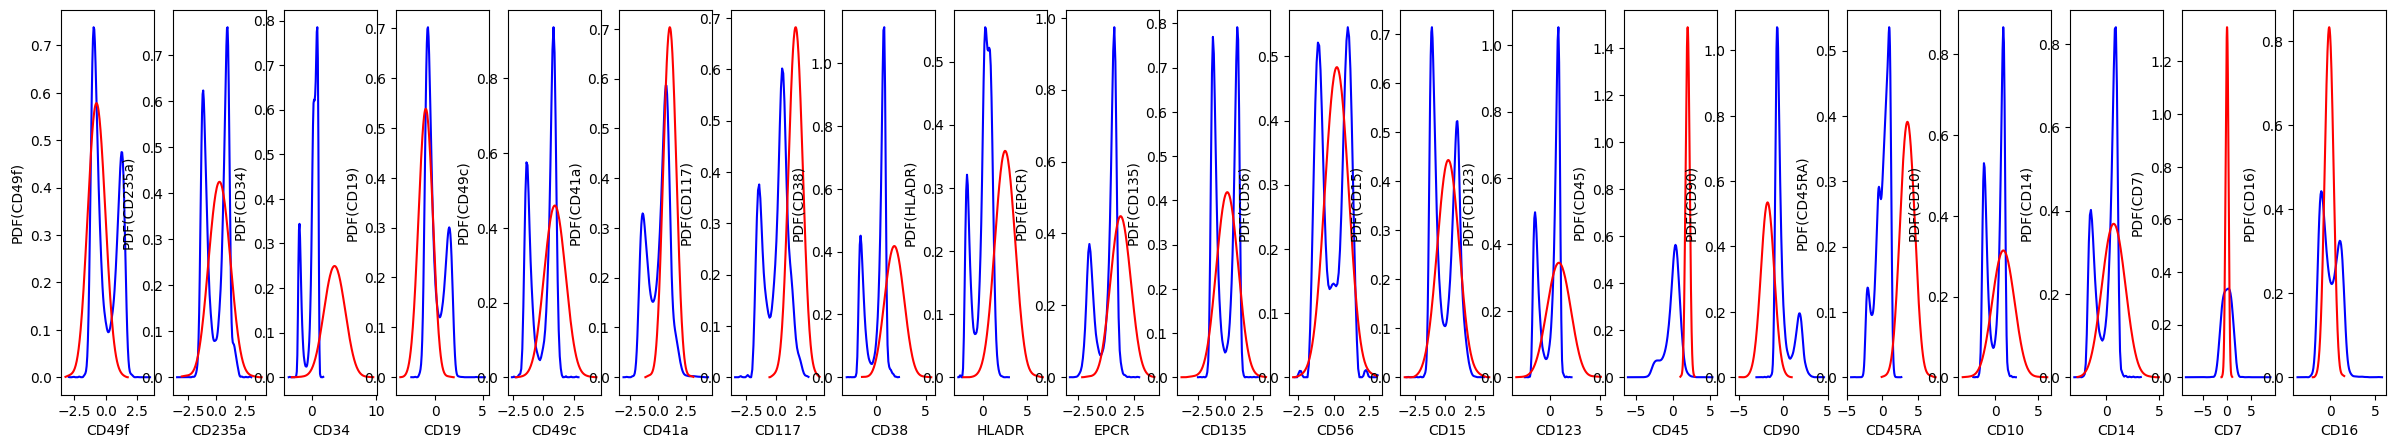

In [41]:
import fastkde
gtPDFs = [fastkde.pdf(X_channel[:, idx], var_names=[col, ]) for idx, col in enumerate(adata.var_names)]
meanPDFs = [fastkde.pdf(x_channel_mean[:, idx], var_names=[col, ]) for idx, col in enumerate(adata.var_names)]
fig, axes = plt.subplots(1, len(adata.var_names), figsize=(30, 5))

for idx, col in enumerate(adata.var_names):
    ax = axes[idx]
    ax.set_title(col)
    gtPDFs[idx].plot(ax=ax, color="blue", label="gt")
    meanPDFs[idx].plot(ax=ax, color="red", label="pred")


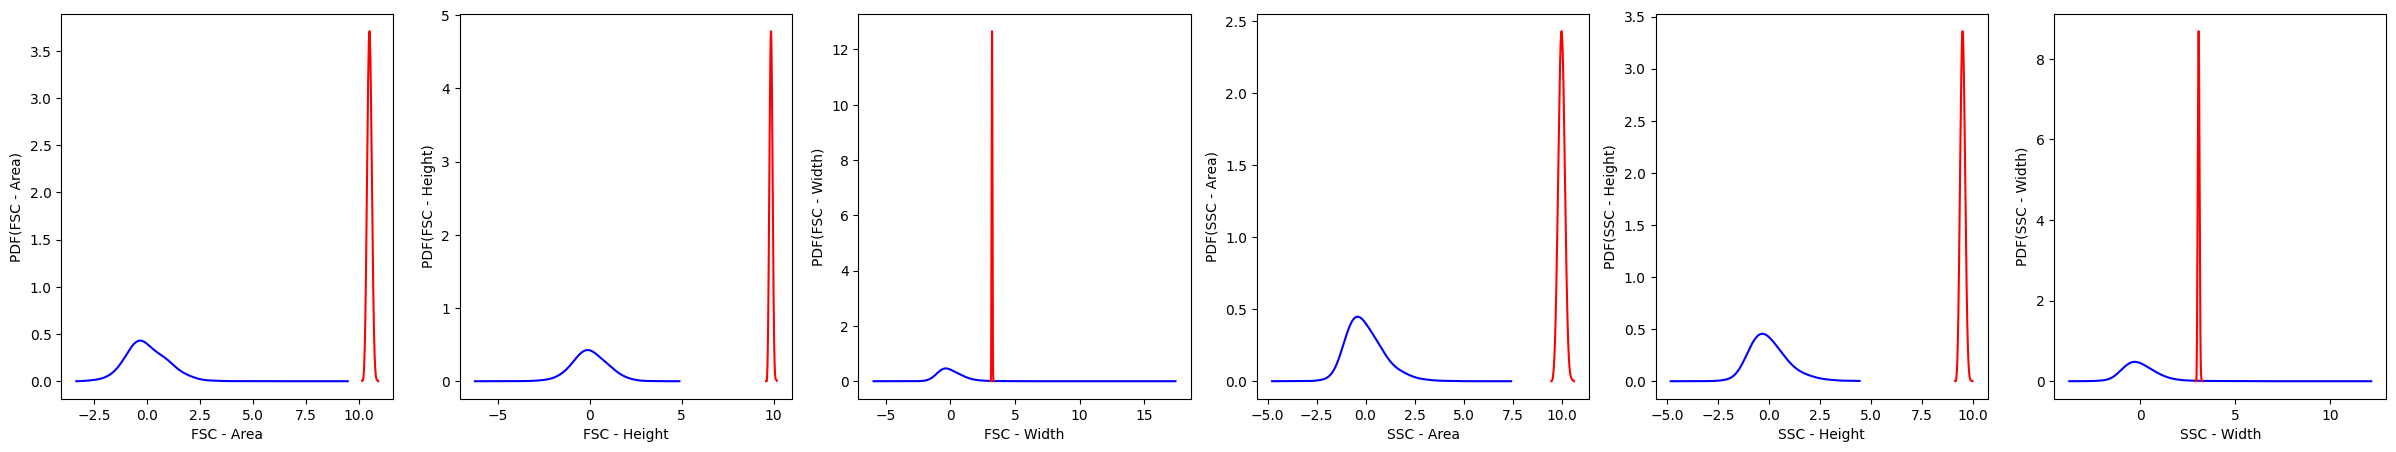

In [39]:
import fastkde
gtPDFs = [fastkde.pdf(X_scatter[:, idx], var_names=[col, ]) for idx, col in enumerate(SCATTER_COLUMNS)]
meanPDFs = [fastkde.pdf(x_scatter_mean[:, idx], var_names=[col, ]) for idx, col in enumerate(SCATTER_COLUMNS)]
fig, axes = plt.subplots(1, len(SCATTER_COLUMNS), figsize=(30, 5))

for idx, col in enumerate(SCATTER_COLUMNS):
    ax = axes[idx]
    ax.set_title(col)
    gtPDFs[idx].plot(ax=ax, color="blue", label="gt")
    meanPDFs[idx].plot(ax=ax, color="red", label="pred")
